In [1]:
!pip install -q timm

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
import timm
from tqdm import tqdm
from PIL import Image
import hashlib
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
DATA_DIR = "/kaggle/input/pcos-dataset/PCOS"

In [4]:
def get_md5(path):
    try:
        with open(path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None


In [5]:
all_samples = []

for label, cls in enumerate(os.listdir(DATA_DIR)):
    cls_path = os.path.join(DATA_DIR, cls)
    for img in os.listdir(cls_path):
        all_samples.append((os.path.join(cls_path, img), label))

hash_map = {}

for path, label in all_samples:
    h = get_md5(path)
    if h is None:
        continue

    if h not in hash_map:
        hash_map[h] = [(path, label)]
    else:
        hash_map[h].append((path, label))

KEEP_PER_GROUP = 3

unique_samples = []
for h, samples in hash_map.items():
    unique_samples.extend(samples[:KEEP_PER_GROUP])

print("Original:", len(all_samples))
print("After controlled removal:", len(unique_samples))


Original: 11784
After controlled removal: 7426


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.85,1.0)),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [7]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label


In [8]:
labels = [s[1] for s in unique_samples]

train_samples, test_samples = train_test_split(
    unique_samples,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_data = CustomDataset(train_samples, train_transform)
test_data  = CustomDataset(test_samples, test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
train_loader_swin = DataLoader(train_data, batch_size=8, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)


In [9]:
resnet = models.resnet18(weights="DEFAULT")
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

densenet = models.densenet121(weights="DEFAULT")
densenet.classifier = nn.Linear(densenet.classifier.in_features, 2)

convnext = timm.create_model("convnext_base", pretrained=True, num_classes=2)
effnet   = timm.create_model("tf_efficientnetv2_s", pretrained=True, num_classes=2)
swin     = timm.create_model("swin_base_patch4_window7_224", pretrained=True, num_classes=2)

models_list = [resnet, densenet, convnext, effnet, swin]
models_list = [m.to(device) for m in models_list]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 229MB/s]


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

In [10]:
def train_single(model, loader, epochs=6, lr=1e-4):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    model.train()
    for e in range(epochs):
        total = 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()

            total += loss.item()

        print(f"{model.__class__.__name__} Epoch {e+1}: {total/len(loader):.4f}")

In [11]:
train_single(resnet, train_loader, 6)
train_single(densenet, train_loader, 6)
train_single(convnext, train_loader, 5)
train_single(effnet, train_loader, 6)
train_single(swin, train_loader_swin, 8, 3e-5)

ResNet Epoch 1: 0.1304
ResNet Epoch 2: 0.0878
ResNet Epoch 3: 0.0734
ResNet Epoch 4: 0.0765
ResNet Epoch 5: 0.0729
ResNet Epoch 6: 0.0611
DenseNet Epoch 1: 0.1412
DenseNet Epoch 2: 0.0823
DenseNet Epoch 3: 0.0701
DenseNet Epoch 4: 0.0648
DenseNet Epoch 5: 0.0638
DenseNet Epoch 6: 0.0657
ConvNeXt Epoch 1: 0.1336
ConvNeXt Epoch 2: 0.0745
ConvNeXt Epoch 3: 0.0710
ConvNeXt Epoch 4: 0.0638
ConvNeXt Epoch 5: 0.0662
EfficientNet Epoch 1: 0.5608
EfficientNet Epoch 2: 0.1398
EfficientNet Epoch 3: 0.0913
EfficientNet Epoch 4: 0.0778
EfficientNet Epoch 5: 0.0670
EfficientNet Epoch 6: 0.0732
SwinTransformer Epoch 1: 0.1274
SwinTransformer Epoch 2: 0.0805
SwinTransformer Epoch 3: 0.0797
SwinTransformer Epoch 4: 0.0737
SwinTransformer Epoch 5: 0.0730
SwinTransformer Epoch 6: 0.0685
SwinTransformer Epoch 7: 0.0650
SwinTransformer Epoch 8: 0.0682


In [12]:
for model in models_list:
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

In [13]:
class Fusion(nn.Module):
    def __init__(self, models):
        super().__init__()
        self.models = nn.ModuleList(models)

        self.attn = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 5)
        )

    def entropy(self, p):
        return -torch.sum(p * torch.log(p+1e-8), dim=1)

    def forward(self, x):
        outs, ents = [], []

        for m in self.models:
            with torch.no_grad():
                o = torch.softmax(m(x), dim=1)

            outs.append(o)
            ents.append(self.entropy(o))

        outs = torch.stack(outs)
        concat = outs.permute(1,0,2).reshape(x.size(0), -1)

        attn = torch.softmax(self.attn(concat), dim=1)

        ents = torch.stack(ents).permute(1,0)
        conf = 1/(ents+1e-6)
        conf = conf / conf.sum(dim=1, keepdim=True)

        w = 0.7*attn + 0.3*conf
        w = w / w.sum(dim=1, keepdim=True)

        w = w.unsqueeze(2)
        outs = outs.permute(1,0,2)

        return (outs * w).sum(dim=1)

In [14]:
train_losses = []
val_accuracies = []

def train_fusion(model, train_loader, val_loader, epochs=5):
    opt = optim.Adam(model.attn.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    for e in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        acc = evaluate_accuracy(model, val_loader)
        val_accuracies.append(acc)

        print(f"Epoch {e+1}: Loss={avg_loss:.4f}, Val Acc={acc:.4f}")

In [15]:
def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = torch.argmax(out, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [16]:
fusion = Fusion(models_list).to(device)

In [17]:
train_fusion(fusion, train_loader, test_loader, epochs=5)

Epoch 1: Loss=0.3354, Val Acc=0.9838
Epoch 2: Loss=0.3349, Val Acc=0.9838
Epoch 3: Loss=0.3344, Val Acc=0.9838
Epoch 4: Loss=0.3345, Val Acc=0.9838
Epoch 5: Loss=0.3340, Val Acc=0.9845


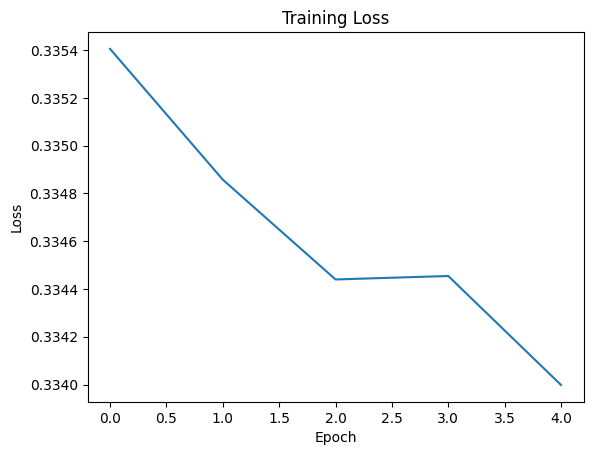

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

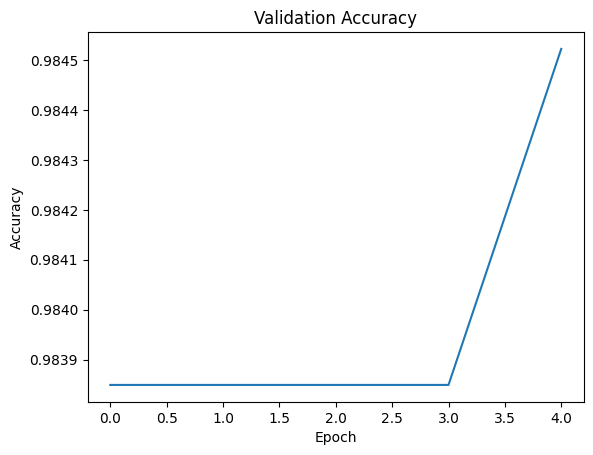

In [19]:
plt.figure()
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

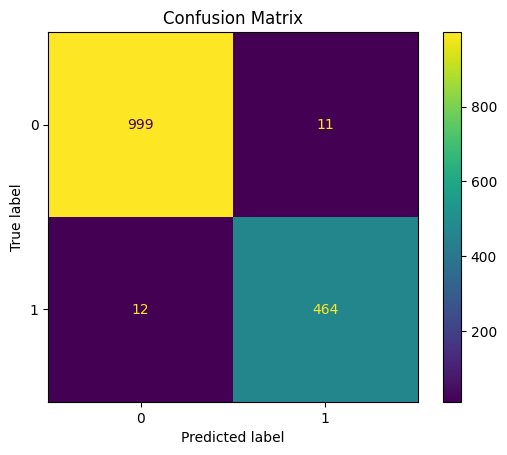

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true, y_pred = [], []

fusion.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = fusion(x)
        preds = torch.argmax(out, dim=1).cpu().numpy()

        y_true.extend(y.numpy())
        y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1010
           1       0.98      0.97      0.98       476

    accuracy                           0.98      1486
   macro avg       0.98      0.98      0.98      1486
weighted avg       0.98      0.98      0.98      1486

